# Paper figures drawn straight from result files — evaluation demo

This notebook is a runnable walkthrough of **`eval.py`** from artifact `art_wqW6y0LsHO8g`, the evaluation of the
paper-figure set for the Applied Network Science submission *"Occupancy is not integration for new scientific
concepts"*.

The original pipeline draws figures F1–F7 and an inferential-caveats table **only from hashed result files of
earlier artifacts**. Nothing is re-estimated. Every plotted number goes through one source registry, and each figure
ships a PDF, a 600 dpi PNG, a caption, a `figure_spec.json` and a `plotted_values.json`. `eval.py` then scores the set
on seven metrics:

| id | metric | what it checks |
|---|---|---|
| M1 | **value fidelity** | every plotted value re-read independently from its source file (exact / derived / image hash) |
| M2 | **record drift** | every number quoted in the research record compared with its source value (MATCH / DRIFT / NOT_FOUND) |
| M3 | **figure completeness** | PDF + PNG + spec + caption rules + plotted values + passing check for each figure |
| M4 | **request coverage** | which of the 8 requested activities each figure covers |
| M5 | **production checks** | width ≤ 174 mm, height ≤ 234 mm, min font, overlaps, no Type 3 fonts |
| M6 | **label integrity** | each evidential label (SCREEN, CONFIRMATORY, …) is in the allowed set and matches the record |
| M7 | **spend** | $0 (CPU only) |

**What changed for the notebook.** The original script shells out to the per-figure checkers in `checks/`, which
re-read 57 source files spread across the research run. A reader does not have those files, so this demo loads
the checkers' **outputs** (`results/check_*.json`, `production_checks.json`, `drift_summary.json`, …) and the
figure sidecars (captions, labels, file lists, a subset of plotted values) from `mini_demo_data.json`. The
aggregation logic of `eval.py`, meaning `completeness()`, `label_integrity()` and the metric and example
assembly in `main()`, is copied unchanged apart from the file reads.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# matplotlib, numpy — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

## Imports
This is the original import block of `eval.py`. The two workspace-local imports cannot resolve outside the artifact
directory:
- `from independent import run_figure` is imported but never called in `eval.py`.
- `from src import style` is only used for the two figure widths. They are loaded from the data below.

Both are kept as comments. `matplotlib` and `SimpleNamespace` are added for the notebook.

In [2]:
from __future__ import annotations

import csv
import json
import re
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions ---
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np

# Original (workspace-local, not available here):
# WS = Path(__file__).resolve().parent
# sys.path.insert(0, str(WS)); sys.path.insert(0, str(WS / "checks"))
# from independent import run_figure  # noqa: E402   (unused in eval.py)
# from src import style  # noqa: E402                (replaced by data["style"] below)

## Data loading
The data file is fetched from GitHub, with a local copy as fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-5/evaluation-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("source:", data["source_artifact"])
print("figures:", list(data["figures"]))
print("check results:", list(data["results"]))
print(f"drift rows in demo: {len(data['drift_report'])} of {data['n_drift_report_full']}")
for f, v in data["figures"].items():
    print(f"  {f}: {len(v['plotted_values'])} plotted-value rows in demo (of {v['n_plotted_values_full']}), "
          f"{len(v['labels'])} labels, files={v['files']}")

source: art_wqW6y0LsHO8g (gen_art_evaluation_9)
figures: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F6b', 'F7']
check results: ['check_F1', 'check_F2', 'check_F3', 'check_F4', 'check_F5', 'check_F6', 'check_F6b', 'check_F7', 'check_caveats', 'production_checks', 'lint_no_literals', 'drift_summary', 'check_selftest']
drift rows in demo: 26 of 174
  F1: 3 plotted-value rows in demo (of 41), 29 labels, files=['F1_method_flow.pdf', 'F1_method_flow.png', 'caption.md', 'figure_spec.json', 'flow_nodes.csv', 'flow_spec.json', 'labels.json', 'plotted_values.json']
  F2: 52 plotted-value rows in demo (of 124), 18 labels, files=['F2_d2_forest.pdf', 'F2_d2_forest.png', 'caption.md', 'figure_spec.json', 'labels.json', 'plotted_values.json']
  F3: 3 plotted-value rows in demo (of 163), 33 labels, files=['F3_mechanism.pdf', 'F3_mechanism.png', 'caption.md', 'figure_spec.json', 'labels.json', 'plotted_values.json']
  F4: 3 plotted-value rows in demo (of 107), 25 labels, files=['F4_rq1_heldout.pdf', 'F4_rq1

## Configuration
`eval.py` has no iterative or stochastic parameters, and the whole evaluation runs in well under a second. The only
thing that affects size is how many **per-value example rows** go into the output `datasets`. The aggregate
metrics always come from the full per-figure check summaries, so they do not depend on these caps.

- `MAX_PV_EXAMPLES_PER_FIGURE` is the number of plotted-value example rows per figure. `None` means all rows in
  the demo data. The original run used every OK row, 947 in total.
- `MAX_DRIFT_EXAMPLES` is the number of drift example rows. `None` means all rows in the demo data. The original
  run used all 174.
- `OUT` is where the notebook writes the files that `eval.py` writes into the artifact workspace.

In [5]:
MAX_PV_EXAMPLES_PER_FIGURE = None   # original: all rows (None)
MAX_DRIFT_EXAMPLES = None         # original: all rows (None)

OUT = Path("demo_out")        # stands in for the artifact workspace WS when writing outputs
(OUT / "results").mkdir(parents=True, exist_ok=True)
style = SimpleNamespace(**data["style"])   # replaces `from src import style`

## Logging and evaluation constants
These are unchanged from `eval.py`:
- the list of figures (`F6b` is the supplementary ego/alluvial embed);
- the **allowed evidential labels** and the record-to-figure label mapping used by M6;
- the **request-coverage table** (M4). It maps each requested research activity (grounding, two network views,
  RQ1, RQ2, typology, cases, methodology figure, related-work comparison) to the figure that shows it. The
  related-work comparison is deliberately left to prose, so coverage is 7/8 = 0.875.

In [6]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(OUT / "logs").mkdir(exist_ok=True)
logger.add(OUT / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

FIGS = ["F1", "F2", "F3", "F4", "F5", "F6", "F7"]
ALL_FIGS = FIGS[:6] + ["F6b", "F7"]
ALLOWED = {"SCREEN", "CONFIRMATORY", "REPLICATION", "SUPPLEMENTARY/POOLED", "MECHANISM", "DESCRIPTIVE",
           "POST-CONFIRMATION EXPLORATORY"}
RECORD_MAP = {"SUPPLEMENTARY": "SUPPLEMENTARY/POOLED", "POOLED": "SUPPLEMENTARY/POOLED"}
COVERAGE = [
    ("1 semantic grounding (frame, classifier/linker, corpus)", "F1 band 1", "shown", ""),
    ("2 two network views (co-word snapshots; concept-subfield bipartite)", "F1 band 2; F6b ego/alluvial",
     "shown", "network layouts are embedded from exp_8 (supplementary)"),
    ("3 RQ1 structural precursors of emergence", "F4", "shown", "R1_DEAD stated on the figure"),
    ("4 RQ2 diffusion across disciplinary boundaries (host entry, grafting)", "F2, F3", "shown", ""),
    ("5 diffusion typology", "F5; F1 band 4", "shown", ""),
    ("6 case studies (quantitatively selected)", "F6; F6b", "shown", ""),
    ("7 methodology in graphical form", "F1", "shown", ""),
    ("8 comparison to related work", "none", "not shown",
     "a literature comparison is prose/table work for the paper step; no figure here"),
]

## M3: caption rules and figure completeness
`sentences()` counts caption sentences. It strips the `F2.` prefix and neutralises abbreviations such as *e.g.* and
*et al.* first. `completeness()` scores each figure on six booleans:
- a PDF and a PNG exist;
- `figure_spec.json` and `plotted_values.json` exist;
- the caption has 2–4 sentences, states a sample size (`N =` or `1,544 entries`), mentions CIs, and names the
  run-root-relative source path;
- the figure's checker exists and reports 0 failures.

The score is the fraction of true cells. **Changes:** file-existence tests read the figure's file list
(`data["figures"][f]["files"]`), and the check JSON comes from `data["results"]`.

In [7]:
def sentences(text: str) -> int:
    body = re.sub(r"^F\d+b?\s*(\(\w+\))?\.\s*", "", text.strip())
    body = re.sub(r"\b(e\.g|i\.e|et al|vs|cf)\.", "x", body)
    return len([s for s in re.split(r"(?<=[.!?])\s+(?=[A-Z(])", body) if s.strip()])


def completeness() -> tuple[list[dict], float]:
    rows = []
    for f in FIGS:
        d = data["figures"][f]                      # was: WS / "figures" / f
        files = d["files"]
        cap = d["caption"]                          # was: (d / "caption.md").read_text()
        chk = data["results"].get(f"check_{f}", {"n_failed": 1})
        n_s = sentences(cap)
        cap_ok = (2 <= n_s <= 4 and bool(re.search(r"\bn\s*=|\bN\s*=|\b\d[\d,]*\s+(concepts|entries|draws|cases|"
                                                      r"strata|pairs|papers|events)", cap))
                  and bool(re.search(r"CI|confidence|no CIs|per row", cap))
                  and bool(re.search(r"3_invention_loop/iter_\d/gen_art/", cap)))
        rows.append({"figure": f, "pdf": any(n.endswith(".pdf") for n in files),
                     "png": any(n.endswith(".png") for n in files),
                     "figure_spec": "figure_spec.json" in files, "caption": cap_ok,
                     "plotted_values": "plotted_values.json" in files,
                     "check_passes": chk["n_failed"] == 0 and f"check_{f}.py" in data["check_scripts"],
                     "caption_sentences": n_s})
    cells = [v for r in rows for k, v in r.items() if k not in ("figure", "caption_sentences")]
    return rows, sum(cells) / len(cells)

## M6: label integrity
Every row on a figure, and every row of the caveats table, carries a *shown* evidential label. There are two
failure modes:
1. The shown label is outside the allowed set.
2. The label disagrees with the one the research record assigns (`record_label`). `SUPPLEMENTARY` and `POOLED`
   both map to `SUPPLEMENTARY/POOLED`.

This stops, for example, a held-out mechanism row being shown as CONFIRMATORY when the record calls it
SUPPLEMENTARY. **Change:** the labels come from `data` instead of `figures/*/labels.json`.

In [8]:
def label_integrity() -> dict:
    labs = []
    for f in ALL_FIGS:
        labs += data["figures"][f]["labels"]        # was: json.loads((WS/"figures"/f/"labels.json").read_text())
    labs += data["tables"]["caveats_labels"]        # was: tables/caveats_labels.json
    bad_set = [l for l in labs if l["shown"] not in ALLOWED]
    mism = [l for l in labs if l.get("record_label") and RECORD_MAP.get(l["record_label"], l["record_label"])
            != l["shown"]]
    n_rec = sum(1 for l in labs if l.get("record_label"))
    return {"n_rows": len(labs), "n_with_record_label": n_rec, "not_in_allowed_set": bad_set,
            "record_mismatches": mism, "label_mismatches": len(bad_set) + len(mism)}

## `main()`, part 1: collect checker outputs and compute the aggregate metrics
The original first runs `checks/check_<F>.py` for every figure and the caveats table. Each checker re-reads every
plotted value from its source file independently. The script then runs `production.py` (PDF geometry and fonts),
`lint_no_literals.py` (no hard-coded numbers in plotting code) and `drift.py` (record quotes against sources).
Here the subprocess calls are commented out and their JSON outputs are read from `data["results"]`.

Value fidelity is (n_values − n_failed) / n_values, summed over all checkers.

In [9]:
logger.info("running per-figure checks")
checks = {}
for f in ALL_FIGS + ["caveats"]:
    # rc = subprocess.run([sys.executable, str(WS / "checks" / f"check_{f}.py")], capture_output=True, text=True)
    checks[f] = data["results"][f"check_{f}"]      # was: json.loads((WS/"results"/f"check_{f}.json").read_text())
    logger.info(f"check_{f}: n_values {checks[f]['n_values']} failed {checks[f]['n_failed']}")
# for script in ("production.py", "lint_no_literals.py", "drift.py"):
#     rc = subprocess.run([sys.executable, str(WS / "checks" / script)], capture_output=True, text=True)
prod = data["results"]["production_checks"]
lint = data["results"]["lint_no_literals"]
drift = data["results"]["drift_summary"]
selftest = data["results"]["check_selftest"]
comp_rows, comp = completeness()
labels = label_integrity()
n_val = sum(c["n_values"] for c in checks.values())
n_fail = sum(c["n_failed"] for c in checks.values())
fidelity = {"n_values": n_val, "n_exact": sum(c["n_exact"] for c in checks.values()),
            "n_derived": sum(c["n_derived"] for c in checks.values()),
            "n_images": sum(c["n_images"] for c in checks.values()), "n_failed": n_fail,
            "n_source_missing_not_plotted": sum(c["n_source_missing"] for c in checks.values()),
            "value_fidelity": (n_val - n_fail) / n_val if n_val else 0.0, "per_figure": checks}
(OUT / "results" / "fidelity_summary.json").write_text(json.dumps(fidelity, indent=1, default=str))
with (OUT / "results" / "figure_completeness.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(comp_rows[0]))
    w.writeheader()
    w.writerows(comp_rows)
with (OUT / "results" / "request_coverage.csv").open("w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["activity", "figure_or_panel", "status", "reason"])
    w.writerows(COVERAGE)
(OUT / "results" / "label_integrity.json").write_text(json.dumps(labels, indent=1, default=str))
metrics = {
    "value_fidelity": fidelity["value_fidelity"], "n_plotted_values": n_val, "n_exact": fidelity["n_exact"],
    "n_derived": fidelity["n_derived"], "n_images_hash_checked": fidelity["n_images"], "n_failed": n_fail,
    "n_source_missing_not_plotted": fidelity["n_source_missing_not_plotted"],
    "n_record_expectations": drift["n"], "n_match": drift["counts"]["MATCH"],
    "n_rounding_diff": drift["counts"]["ROUNDING_DIFF"], "n_drift": drift["counts"]["DRIFT"],
    "n_not_found": drift["counts"]["NOT_FOUND"], "figure_completeness": comp,
    "request_coverage_shown_fraction": sum(c[2] == "shown" for c in COVERAGE) / len(COVERAGE),
    "min_font_pt": min(p["min_font_pt"] for p in prod), "n_text_overlaps": sum(p["n_text_overlaps"] for p in prod),
    "production_pass_fraction": sum(p["pass"] for p in prod) / len(prod),
    "label_mismatches": labels["label_mismatches"], "lint_literal_hits": lint["n_hits"],
    "mutation_selftest_pass": float(selftest["selftest_pass"]), "openrouter_usd": 0.0,
}

12:51:33|INFO   |running per-figure checks


12:51:33|INFO   |check_F1: n_values 39 failed 0


12:51:33|INFO   |check_F2: n_values 124 failed 0


12:51:33|INFO   |check_F3: n_values 163 failed 0


12:51:33|INFO   |check_F4: n_values 102 failed 0


12:51:33|INFO   |check_F5: n_values 67 failed 0


12:51:33|INFO   |check_F6: n_values 425 failed 0


12:51:33|INFO   |check_F6b: n_values 8 failed 0


12:51:33|INFO   |check_F7: n_values 0 failed 0


12:51:33|INFO   |check_caveats: n_values 29 failed 0


## `main()`, part 2: per-example datasets
The output follows the `exp_eval_sol_out` schema. Next to the aggregate metrics it stores five example-level
datasets:
- `plotted_values`: one row per plotted value, with its source path, artifact id and sha256, and whether the
  independent re-read matched;
- `drift`: one row per quoted record number, with its status;
- `figure_completeness`, `request_coverage` and `production_checks`: one row per figure or activity.

**Change:** plotted values and drift rows come from the demo subset, capped by the config variables. The
original iterates over every row in `figures/*/plotted_values.json` and `results/drift_report.csv`.

In [10]:
ex_pv = []
for f in ALL_FIGS + ["caveats"]:
    pv_rows = data["tables"]["caveats_values"] if f == "caveats" else data["figures"][f]["plotted_values"]
    pv_rows = pv_rows[:MAX_PV_EXAMPLES_PER_FIGURE]   # notebook cap (None = all rows in the demo data)
    failed = {(x["panel"], x["row"], x["field"]) for x in checks[f]["failures"]}
    for r in pv_rows:
        if r.get("status") != "OK":
            continue
        ex_pv.append({"input": f"{r['figure']} | panel {r['panel']} | row {r['row']} | {r['field']}",
                      "output": str(r["value"]), "metadata_key": r["key"],
                      "metadata_source_path": r.get("path", ""), "metadata_artifact_id": r.get("artifact_id", ""),
                      "metadata_sha256": r.get("sha256", ""), "metadata_fold_label": r.get("fold_label", ""),
                      "metadata_ci_type": r.get("ci_type", ""), "metadata_source_kind": r.get("source_kind", ""),
                      "metadata_display_string": r.get("display_string") or "",
                      "predict_figure": str(r["value"]),
                      "eval_value_match": 0.0 if (r["panel"], r["row"], r["field"]) in failed else 1.0})
ex_drift = []
for r in data["drift_report"][:MAX_DRIFT_EXAMPLES]:   # was: csv.DictReader((WS/"results"/"drift_report.csv").open())
    ex_drift.append({"input": f"record quote {r['key']}: {r['quoted']}", "output": r["source_value"] or "NOT_FOUND",
                     "metadata_status": r["status"], "metadata_source": r["source"],
                     "metadata_note": r["note"], "predict_record": r["quoted"],
                     "eval_match": 1.0 if r["status"] == "MATCH" else 0.0})
ex_comp = [{"input": f"figure {r['figure']} deliverables", "output": json.dumps(r),
            "predict_complete": str(all(v for k, v in r.items() if k not in ("figure", "caption_sentences"))),
            "eval_complete": float(all(v for k, v in r.items() if k not in ("figure", "caption_sentences")))}
           for r in comp_rows]
ex_cov = [{"input": a, "output": f"{fp} ({st})", "metadata_reason": rsn, "predict_status": st,
           "eval_shown": 1.0 if st == "shown" else 0.0} for a, fp, st, rsn in COVERAGE]
ex_prod = [{"input": f"production {p['figure']}", "output": "PASS" if p["pass"] else "FAIL",
            "predict_check": "PASS" if p["pass"] else "FAIL",
            "metadata_detail": json.dumps({k: v for k, v in p.items() if k != "colourblind"}),
            "eval_pass": float(p["pass"]), "eval_min_font_pt": float(p["min_font_pt"])} for p in prod]
out = {"metadata": {"evaluation_name": "paper figure set drawn straight from result files",
                    "artifact_plan": "gen_plan_evaluation_4_idx5",
                    "description": "Fidelity, drift, completeness, coverage, production and label checks for "
                                   "figures F1-F7 and the inferential caveats table; nothing re-estimated.",
                    "figure_widths_mm": [style.W_DOUBLE_MM, style.W_SINGLE_MM]},
       "metrics_agg": metrics,
       "datasets": [{"dataset": "plotted_values", "examples": ex_pv}, {"dataset": "drift", "examples": ex_drift},
                    {"dataset": "figure_completeness", "examples": ex_comp},
                    {"dataset": "request_coverage", "examples": ex_cov},
                    {"dataset": "production_checks", "examples": ex_prod}]}
(OUT / "eval_out.json").write_text(json.dumps(out, indent=1, default=str))
logger.info(json.dumps(metrics))
print({d["dataset"]: len(d["examples"]) for d in out["datasets"]})

12:51:33|INFO   |{"value_fidelity": 1.0, "n_plotted_values": 957, "n_exact": 939, "n_derived": 10, "n_images_hash_checked": 8, "n_failed": 0, "n_source_missing_not_plotted": 9, "n_record_expectations": 174, "n_match": 170, "n_rounding_diff": 0, "n_drift": 3, "n_not_found": 1, "figure_completeness": 1.0, "request_coverage_shown_fraction": 0.875, "min_font_pt": 6.5, "n_text_overlaps": 0, "production_pass_fraction": 1.0, "label_mismatches": 0, "lint_literal_hits": 0, "mutation_selftest_pass": 1.0, "openrouter_usd": 0.0}


{'plotted_values': 73, 'drift': 26, 'figure_completeness': 7, 'request_coverage': 8, 'production_checks': 8}


## Results
The cells below show:
1. the aggregate metrics, next to the values reported in the artifact's `eval_out.json`;
2. the per-figure fidelity, completeness and production tables;
3. the drift rows, where the record quotes disagree with their source files;
4. plots of the per-figure value counts, the drift status counts, and the **F2 forest** (IRR per SD with 95% CIs),
   redrawn from the plotted values in the demo data. The forest shows the main confirmatory result: anchoring
   into host-native partners predicts newcomer uptake (A_cont), while co-transfer (CT) does not.

In [11]:
REPORTED = {"value_fidelity": 1.0, "n_plotted_values": 957, "n_exact": 939, "n_derived": 10,
            "n_images_hash_checked": 8, "n_failed": 0, "n_record_expectations": 174, "n_match": 170, "n_drift": 3,
            "n_not_found": 1, "figure_completeness": 1.0, "request_coverage_shown_fraction": 0.875,
            "min_font_pt": 6.5, "n_text_overlaps": 0, "production_pass_fraction": 1.0, "label_mismatches": 0,
            "lint_literal_hits": 0, "mutation_selftest_pass": 1.0}
print(f"{'metric':<34}{'notebook':>12}{'reported':>12}  ok")
for k, v in metrics.items():
    rep = REPORTED.get(k, "")
    ok = "" if rep == "" else ("✓" if abs(float(v) - float(rep)) < 1e-9 else "✗")
    print(f"{k:<34}{v:>12.4g}{str(rep):>12}  {ok}")

print("\nPer-figure checker summary (M1):")
print(f"{'fig':<9}{'n_values':>9}{'exact':>7}{'derived':>8}{'images':>7}{'failed':>7}{'src_missing':>12}")
for f, c in checks.items():
    print(f"{f:<9}{c['n_values']:>9}{c['n_exact']:>7}{c['n_derived']:>8}{c['n_images']:>7}{c['n_failed']:>7}"
          f"{c['n_source_missing']:>12}")

print("\nFigure completeness (M3):")
for r in comp_rows:
    print("  ", r)
print("\nProduction (M5):")
for p in prod:
    print(f"   {p['figure']:<9} pass={p['pass']}  min_font={p['min_font_pt']}pt  overlaps={p['n_text_overlaps']}  "
          + ", ".join(f"{x['pdf']} {x['width_mm']:.0f}x{x['height_mm']:.0f}mm" for x in p.get('files', [])))
print("\nRecord drift, non-MATCH rows (M2) — corrections handed to the paper step:")
for r in data["drift_report"]:
    if r["status"] != "MATCH":
        print(f"   [{r['status']}] {r['key']}: quoted {r['quoted']!r} vs source {r['source_value'] or '—'}  ({r['note'][:90]})")

metric                                notebook    reported  ok
value_fidelity                               1         1.0  ✓
n_plotted_values                           957         957  ✓
n_exact                                    939         939  ✓
n_derived                                   10          10  ✓
n_images_hash_checked                        8           8  ✓
n_failed                                     0           0  ✓
n_source_missing_not_plotted                 9              
n_record_expectations                      174         174  ✓
n_match                                    170         170  ✓
n_rounding_diff                              0              
n_drift                                      3           3  ✓
n_not_found                                  1           1  ✓
figure_completeness                          1         1.0  ✓
request_coverage_shown_fraction          0.875       0.875  ✓
min_font_pt                                6.5         6.5  ✓
n_text_ov

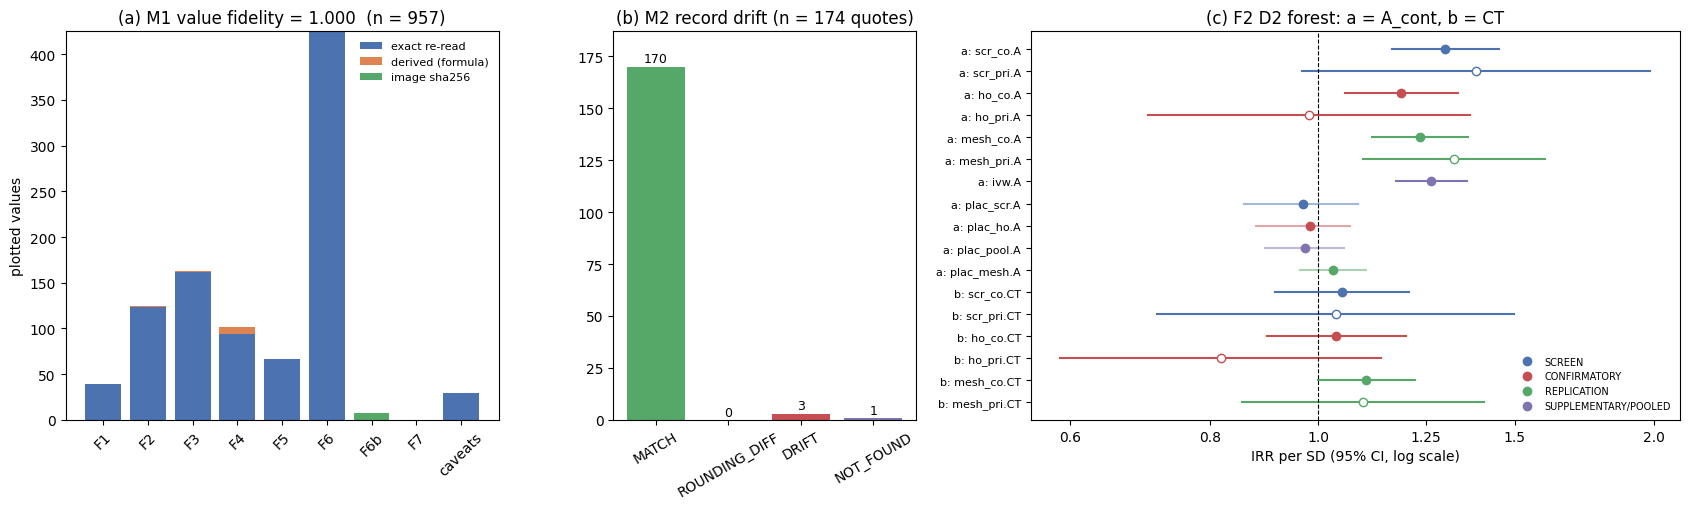

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1, 0.7, 1.5]})

# (a) plotted values per figure, split by how they were verified
ax = axes[0]
names = list(checks)
exact = np.array([checks[f]["n_exact"] for f in names]); der = np.array([checks[f]["n_derived"] for f in names])
img = np.array([checks[f]["n_images"] for f in names])
ax.bar(names, exact, label="exact re-read", color="#4C72B0")
ax.bar(names, der, bottom=exact, label="derived (formula)", color="#DD8452")
ax.bar(names, img, bottom=exact + der, label="image sha256", color="#55A868")
ax.set_title(f"(a) M1 value fidelity = {metrics['value_fidelity']:.3f}  (n = {n_val})")
ax.set_ylabel("plotted values"); ax.legend(frameon=False, fontsize=8); ax.tick_params(axis="x", rotation=45)

# (b) record drift status counts
ax = axes[1]
cnt = drift["counts"]
ax.bar(list(cnt), list(cnt.values()), color=["#55A868", "#CCB974", "#C44E52", "#8172B2"])
for i, v in enumerate(cnt.values()):
    ax.text(i, v + 2, str(v), ha="center", fontsize=9)
ax.set_ylim(0, max(cnt.values()) * 1.1)
ax.set_title(f"(b) M2 record drift (n = {drift['n']} quotes)"); ax.tick_params(axis="x", rotation=30)

# (c) F2 forest redrawn from the plotted values in the demo data
ax = axes[2]
pts = {}
for r in data["figures"]["F2"]["plotted_values"]:
    pts.setdefault((r["panel"], r["row"]), {"fold": r["fold_label"]})[r["field"]] = r["value"]
pts = {k: v for k, v in pts.items() if {"est", "lo", "hi"} <= set(v)}
fold_col = {"SCREEN": "#4C72B0", "CONFIRMATORY": "#C44E52", "REPLICATION": "#55A868",
            "SUPPLEMENTARY/POOLED": "#8172B2"}
for i, ((panel, row), v) in enumerate(pts.items()):
    y = -i
    c = fold_col.get(v["fold"], "grey")
    filled = "_co" in row or row.startswith("ivw") or row.startswith("plac")
    ax.plot([v["lo"], v["hi"]], [y, y], color=c, lw=1.5, alpha=0.5 if row.startswith("plac") else 1)
    ax.plot(v["est"], y, "o", color=c, mfc=c if filled else "white", ms=6)
ax.set_yticks([-i for i in range(len(pts))])
ax.set_yticklabels([f"{p}: {r}" for p, r in pts], fontsize=8)
ax.axvline(1.0, color="k", lw=0.8, ls="--"); ax.set_xscale("log")
ax.set_xticks([0.6, 0.8, 1.0, 1.25, 1.5, 2.0]); ax.set_xticklabels(["0.6", "0.8", "1.0", "1.25", "1.5", "2.0"])
ax.minorticks_off()
ax.set_xlabel("IRR per SD (95% CI, log scale)")
ax.set_title("(c) F2 D2 forest: a = A_cont, b = CT")
for lab, c in fold_col.items():
    ax.plot([], [], "o", color=c, label=lab)
ax.legend(frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()